In [1]:
import numpy as np

def sample_W_with_target_fro_distance(
    d: int,
    target_dist: float,
) -> np.ndarray:
    E = np.random.rand(d, d)
    fro_E = np.linalg.norm(E, ord="fro")
    E /= fro_E
    W = np.eye(d) + target_dist * E
    return W


def generate_data(n, d, W_fro_dist=0.1, sigma=0.0, seed=0):
    np.random.seed(seed)

    # X_ij ~ N(0, 1/d)
    X = np.random.randn(n, d)/ np.sqrt(d)

    # Construct W with controlled ||W - I||_F
    W = sample_W_with_target_fro_distance(d, W_fro_dist)

    Y_true = X @ W
    Y_noisy = Y_true + sigma * np.random.standard_normal((n, d))

    perm = np.random.permutation(n)
    P = np.eye(n)[perm]          # permutation matrix
    Y_obs = P @ Y_noisy

    return X, Y_obs, W, perm


def fro_norm_W_minus_I(W: np.ndarray) -> float:
    W = np.asarray(W)
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError(f"W must be square, got {W.shape}")
    I = np.eye(W.shape[0], dtype=W.dtype)
    return float(np.linalg.norm(W - I, ord="fro"))


# Example
n, d = 100, 100
X, Y_obs, W, perm = generate_data(n, d, W_fro_dist=5.9, sigma=0.00, seed=1234)
print("||W - I||_F =", fro_norm_W_minus_I(W))


||W - I||_F = 5.9


In [ ]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import rbf_kernel



def LAOT(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    n_epochs=1000, batch_size=2048, lr=1e-3, device="auto", seed=12345, verbose=True
):
    import torch, numpy as np, random, ot
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler

    # ---------------- Device check ---------------- #
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    
    # Helper: only pin memory for CPU→CUDA pipeline
    def should_pin(device, tensor):
        return (device.startswith("mps") and tensor.device.type == "cpu")

    # ---------------- Helper Functions ---------------- #
    def cost_matrix(X, Y):
        X2 = (X**2).sum(1, keepdims=True)
        Y2 = (Y**2).sum(1, keepdims=True).T
        return X2 + Y2 - 2 * X @ Y.T

    def exact_ot_plan(X, Y):
        a, b = torch.ones(len(X)), torch.ones(len(Y))
        C = cost_matrix(X, Y)
        Pi = ot.emd(a, b, C, numItermax=int(1e7))
        return Pi, C

    class Mapper(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.first = nn.Linear(d, d, bias=False)
            nn.init.eye_(self.first.weight)
        def forward(self, x):
            return self.first(x)
        def loss(self, Xmap, Y, P):
            return torch.norm(Y - P.T @ Xmap)**2

    # ---------------- Data Setup ---------------- #
    scaler = StandardScaler()

    XY = np.vstack([X_tr_pre, Y_tr_post])
    XYs = torch.tensor(scaler.fit_transform(XY), dtype=torch.float32, device=device)

    n = len(X_tr_pre)
    Xtr_s = XYs[:n]
    Ytr_s = XYs[n:]

    Xte_s = torch.tensor(scaler.transform(X_te_pre), dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_te_post, dtype=torch.float32, device=device)

    # Build dataloader (pin only if CPU→CUDA)
    pin = should_pin(device, Xtr_s)
    train_loader = DataLoader(
        TensorDataset(Xtr_s, Ytr_s),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin
    )

    # ---------------- Seed ---------------- #
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    mapper = Mapper(X_tr_pre.shape[1]).to(device)
    opt = torch.optim.Adam(mapper.parameters(), lr=lr, weight_decay=1e-4)

    # ---------------- Training Loop ---------------- #
    for epoch in range(n_epochs+1):
        mapper.train()
        for bx, by in train_loader:

            Xmap = mapper(bx)
            with torch.no_grad():
                P,_ = exact_ot_plan(Xmap, by)
                if isinstance(P, np.ndarray):
                    P = torch.from_numpy(P).to(device=device, dtype=torch.float32)
                else:
                    P = P.clone().detach().to(device=device, dtype=torch.float32)
                    
            opt.zero_grad(set_to_none=True)
            loss = mapper.loss(Xmap, by, P)
            loss.backward()
            opt.step()

        # Logging
        if verbose and epoch % 100 == 0:
            mapper.eval()
            with torch.no_grad():
                train_map = mapper(Xtr_s)
                train_map_unscaled = scaler.inverse_transform(train_map.cpu().numpy())
                Y_train_unscaled = scaler.inverse_transform(Ytr_s.cpu().numpy())
                train_mmd = mmd_distance(train_map_unscaled, Y_train_unscaled, 0.1)

                te_s = mapper(Xte_s)
                te = scaler.inverse_transform(te_s.cpu())
                test_mmd = mmd_distance(te, Yte.cpu().numpy(), 0.1)

            print(f"Epoch {epoch} | Train Loss {loss.item():.4f} | Train MMD {train_mmd:.4f} | Test MMD {test_mmd:.4f} ")


    # ---------------- Final Eval ---------------- #
    mapper.eval()
    with torch.no_grad():
        te_s = mapper(Xte_s)
        te = scaler.inverse_transform(te_s.cpu().numpy())


    return te
def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)


Processing dims:   0%|                                                                                                                                                                                                                     | 0/10 [00:00<?, ?it/s]

Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0001 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0003 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 100, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0001 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0001 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 100, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0001 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0002 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 100, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.000

Processing dims:  10%|████████████████████▌                                                                                                                                                                                        | 1/10 [00:34<05:10, 34.45s/it]

Epoch 200 | Train Loss 14673.2432 | Train MMD 0.3227 | Test MMD 0.3227 
Epoch 300 | Train Loss 12652.1738 | Train MMD 0.1984 | Test MMD 0.1984 
Dim: 100, Dev: 200.0, MMD: 0.4668
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0001 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0002 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 90, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0002 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 90, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train 

Processing dims:  20%|█████████████████████████████████████████                                                                                                                                                                    | 2/10 [01:08<04:33, 34.21s/it]

...

Epoch 300 | Train Loss 5324.7993 | Train MMD 0.4551 | Test MMD 0.4551 
Dim: 30, Dev: 200.0, MMD: 0.8639
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 20, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 20, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 20, Dev: 0.0, MMD: 

Processing dims:  90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                    | 9/10 [05:15<00:35, 35.54s/it]

Epoch 200 | Train Loss 3805.9639 | Train MMD 0.6354 | Test MMD 0.6354 
Epoch 300 | Train Loss 3715.8108 | Train MMD 0.5212 | Test MMD 0.5212 
Dim: 20, Dev: 200.0, MMD: 0.9081
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 10, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Dim: 10, Dev: 0.0, MMD: 0.0000
Epoch 0 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 100 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 200 | Train Loss 0.0000 | Train MMD 0.0000 | Test MMD 0.0000 
Epoch 300 | Train Los

Processing dims: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [05:53<00:00, 35.33s/it]

Epoch 300 | Train Loss 1918.9556 | Train MMD 0.6170 | Test MMD 0.6170 
Dim: 10, Dev: 200.0, MMD: 0.9435


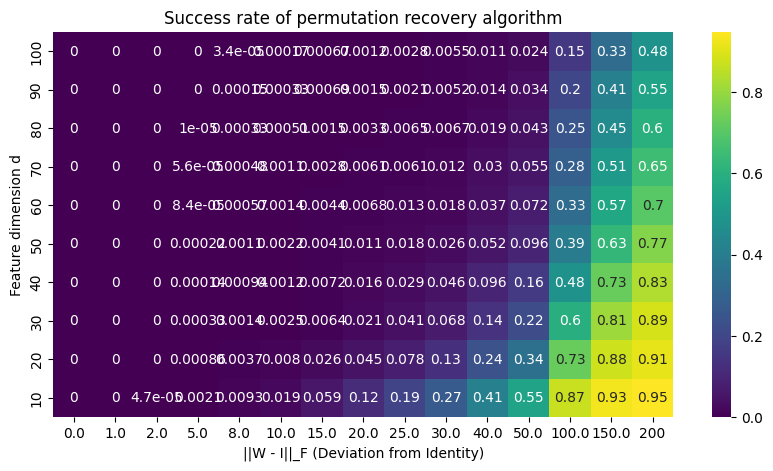

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# -----------------------------
# Experiment Grid
# -----------------------------
dims = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]  # reduced for runtime
A_devs = [0.0, 1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 100.0, 150.0, 200]
trials = 5 # reduced for speed
n = 100  # reduced for speed

results = np.zeros((len(dims), len(A_devs)))

for i, d in enumerate(tqdm(dims, desc="Processing dims")):
    for j, dev in enumerate(A_devs):
        accs = []
        for _ in range(trials):
            X, Y_obs, A_true, perm_true = generate_data(n=n, d=d, W_fro_dist=dev, sigma=0.0, seed=i+j+_)
            A_hat = LAOT(X, Y_obs, X, Y_obs, n_epochs=300)
            accs.append(mmd_distance(A_hat, Y_obs, gamma=0.01))  # success if MMD is small
            print(f"Dim: {d}, Dev: {dev:.1f}, MMD: {accs[-1]:.4f}")
        results[i, j] = np.mean(accs)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))
sns.heatmap(results, xticklabels=A_devs, yticklabels=dims, annot=True, cmap="viridis")
plt.xlabel("||W - I||_F (Deviation from Identity)")
plt.ylabel("Feature dimension d")
plt.title("Success rate of permutation recovery algorithm")
plt.show()


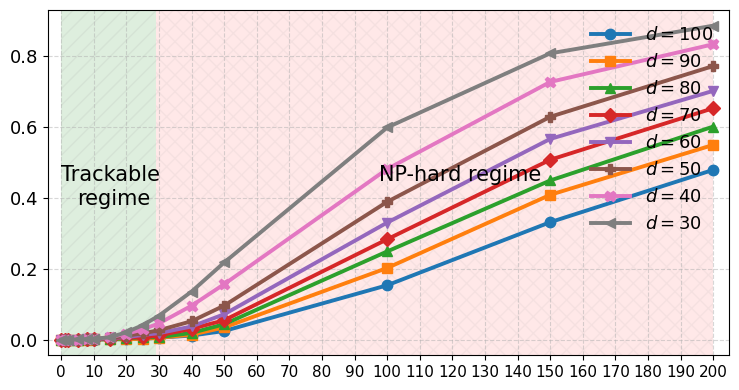

Saved: LAOT_near_identity_permutation_recovery_d30_d100_ten_iteration_n100_final.pdf


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# REQUIRED INPUTS (you already have these)
#   A_devs: 1D array-like, values on x-axis (should span 0..100)
#   results: 2D array-like, shape = (num_d, len(A_devs))
#            rows correspond to d = 10,20,...,100 (or the reverse; see row_order)
# -----------------------------
x = np.asarray(A_devs, dtype=float)
results = np.asarray(results, dtype=float)

# -----------------------------
# CONFIG
# -----------------------------
d_values = np.arange(100, 9, -10)  # d = 10,20,...,100]

# If your results rows are ordered as:
#   "ascending": row 0 -> d=10, row 1 -> d=20, ..., row 9 -> d=100
#   "descending": row 0 -> d=100, row 1 -> d=90, ..., row 9 -> d=10
row_order = "ascending"  # change to "descending" if needed

# vertical threshold line x = x0 (in [0, 100])
x0 =29.0  # <-- set your boundary here

# Define which side is "possible"
possible_side = "left"   # "left" means x <= x0 possible; "right" means x >= x0 possible

# Plot styling
lw = 2.8
ms = 7.5
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*']  # 10 distinct markers

# Output
fig_path = "LAOT_near_identity_permutation_recovery_d30_d100_ten_iteration_n100_final.pdf"

# -----------------------------
# SANITY CHECKS
# -----------------------------
if results.ndim != 2:
    raise ValueError(f"`results` must be 2D, got shape {results.shape}.")
if x.ndim != 1:
    raise ValueError(f"`A_devs` must be 1D, got shape {x.shape}.")
if results.shape[0] != len(d_values):
    raise ValueError(
        f"`results` must have {len(d_values)} rows (for d=10..100), "
        f"but has {results.shape[0]} rows."
    )
if results.shape[1] != len(x):
    raise ValueError(
        f"`results` must have {len(x)} columns (same as len(A_devs)), "
        f"but has {results.shape[1]} columns."
    )

# align d_values with results row order
if row_order.lower() == "descending":
    d_plot = d_values[::-1]
else:
    d_plot = d_values

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7.5, 4))
ax = plt.gca()

# Shade regions (different hatching so it’s visually distinct even in grayscale)
if possible_side.lower() == "left":
    ax.axvspan(0, x0, alpha=0.13, hatch='//',  facecolor="green", edgecolor='0.6', linewidth=0.0, zorder=0)
    ax.axvspan(x0, 200, alpha=0.09, hatch='xx', facecolor="red", edgecolor='0.6', linewidth=0.0, zorder=0)
    possible_label_x = 0.5 * x0
    impossible_label_x = x0 + 0.5 * (150 - x0)
    possible_text, impossible_text = "Trackable \nregime", "NP-hard regime"
else:
    ax.axvspan(0, x0, alpha=0.15, hatch='//',  facecolor="green", edgecolor='0.8', linewidth=0.0, zorder=0)
    ax.axvspan(x0, 200, alpha=0.05, hatch='xx', edgecolor='0.8', linewidth=0.0, zorder=0)
    possible_label_x = 0.5 * x0
    impossible_label_x = x0 + 0.5 * (150 - x0)
    possible_text, impossible_text = "Trackable \nregime", "NP-hard regime"

# Threshold line
# ax.axvline(x0, linestyle='--', linewidth=2.2, zorder=2)

# Curves for d=10..100
for i, d in enumerate(d_plot[:8]):
    # i+=1
    ax.plot(
        x, results[i, :],
        marker=markers[i % len(markers)],
        linewidth=lw,
        markersize=ms,
        label=rf"$d={d}$",
        zorder=3
    )

# Axes limits: x from 0 to 100 (as requested)
ax.set_xlim(-4, 205)
ax.set_xticks(np.arange(0, 201, 10))

# If you want fixed y-limits (uncomment if your recovery is in [0,1])
# ax.set_ylim(-0.05, 1.05)f

# Optional labels
# ax.set_xlabel(r"$\|W^\star - I_d\|_F$", fontsize=14)
# ax.set_ylabel("Permutation recovery rate", fontsize=14)

# Region labels (use axis transform so text stays near the top regardless of y-scale)
ax.text(possible_label_x+1.5, 0.55, possible_text, transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=15)
ax.text(impossible_label_x+33, 0.55, impossible_text, transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=15)

# Grid + legend
ax.grid(True, linestyle="--", alpha=0.5)

# Legend can get crowded; this keeps it readable
ax.legend(frameon=False, fontsize=13, loc="upper right", ncol=1, handlelength=2.2)

ax.tick_params(axis='x', which='major', labelsize=11)
ax.tick_params(axis='y', which='major', labelsize=13)

plt.tight_layout()
plt.savefig(fig_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path}")
